Sukhada Bhoyar - 23070521033

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4027281152.0000 - mae: 44851.7070 - val_loss: 4447291904.0000 - val_mae: 46520.7812
Epoch 2/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4029694464.0000 - mae: 44794.6719 - val_loss: 4437053440.0000 - val_mae: 46304.2070
Epoch 3/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4020480512.0000 - mae: 44763.7852 - val_loss: 4441043456.0000 - val_mae: 45986.9297
Epoch 4/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4017883904.0000 - mae: 44709.1914 - val_loss: 4437009408.0000 - val_mae: 46237.7812
Epoch 5/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4010411520.0000 - mae: 44640.8750 - val_loss: 4439923200.0000 - val_mae: 46198.9180
Epoch 6/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4009688320.0000 - mae: 44637.8594 - val_loss: 4436853248.0000 - val_mae: 46296.3008
Epoch 7/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4004591872.0000 - mae: 44652.0352 - val_loss: 4438788608.0000 - val_

In [ ]:
predictions = model.predict(X_test)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 41292.150338924635
Mean Squared Error (MSE): 3488009546.6378984
Root Mean Squared Error (RMSE): 59059.37306336648


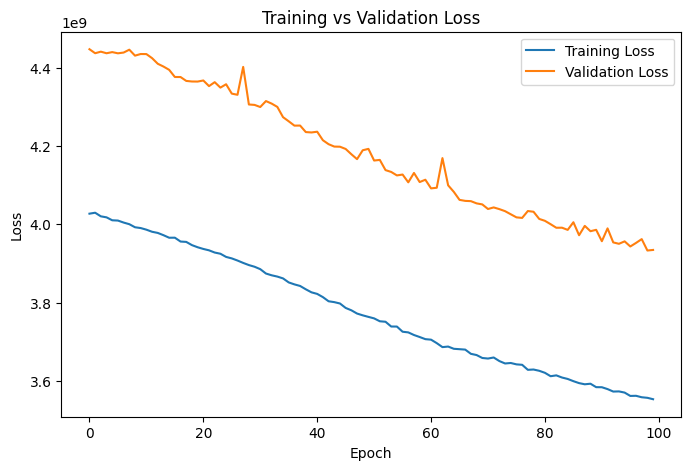

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### Model 1: Architecture 64 → 1

In [ ]:
model1 = Sequential()
model1.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(1))

model1.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Set verbose to 0 to suppress training output
)

predictions1 = model1.predict(X_test)

mae1 = mean_absolute_error(y_test, predictions1)
mse1 = mean_squared_error(y_test, predictions1)
rmse1 = np.sqrt(mse1)

print("\nModel 1 Results")
print(f"MAE: {mae1}")
print(f"MSE: {mse1}")
print(f"RMSE: {rmse1}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Model 1 Results
MAE: 99601.13915319106
MSE: 17328063764.80026
RMSE: 131636.10357648946


### Model 2: Architecture 128 → 64 → 1

In [ ]:
model2 = Sequential()
model2.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(1))

model2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

predictions2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, predictions2)
mse2 = mean_squared_error(y_test, predictions2)
rmse2 = np.sqrt(mse2)

print("\nModel 2 Results")
print(f"MAE: {mae2}")
print(f"MSE: {mse2}")
print(f"RMSE: {rmse2}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Model 2 Results
MAE: 45442.82811121323
MSE: 4061890756.7842226
RMSE: 63732.964443717996


### Model 3: Architecture 128 → 64 → 32 → 1

In [ ]:
model3 = Sequential()
model3.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dense(64, activation='relu'))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(1))

model3.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

predictions3 = model3.predict(X_test)

mae3 = mean_absolute_error(y_test, predictions3)
mse3 = mean_squared_error(y_test, predictions3)
rmse3 = np.sqrt(mse3)

print("\nModel 3 Results")
print(f"MAE: {mae3}")
print(f"MSE: {mse3}")
print(f"RMSE: {rmse3}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Model 3 Results
MAE: 44172.408588579965
MSE: 3884254820.21816
RMSE: 62323.7901624906


### Model 4: Architecture 256 → 128 → 64 → 32 → 1

In [ ]:
model4 = Sequential()
model4.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model4.add(Dense(128, activation='relu'))
model4.add(Dense(64, activation='relu'))
model4.add(Dense(32, activation='relu'))
model4.add(Dense(1))

model4.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history4 = model4.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

predictions4 = model4.predict(X_test)

mae4 = mean_absolute_error(y_test, predictions4)
mse4 = mean_squared_error(y_test, predictions4)
rmse4 = np.sqrt(mse4)

print("\nModel 4 Results")
print(f"MAE: {mae4}")
print(f"MSE: {mse4}")
print(f"RMSE: {rmse4}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Model 4 Results
MAE: 38611.46840992647
MSE: 3249402262.995555
RMSE: 57003.52851355392


### Model 1 (64 → 1) Loss Plot

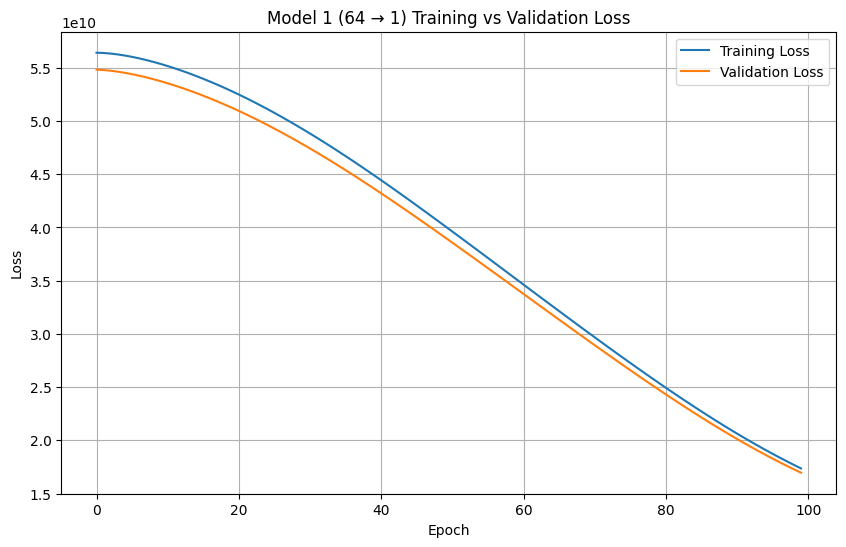

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1 (64 → 1) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Model 2 (128 → 64 → 1) Loss Plot

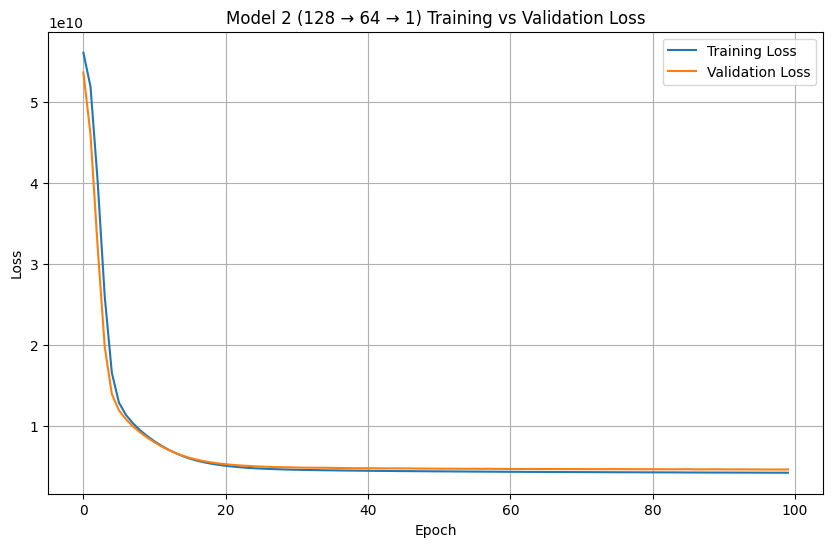

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 (128 → 64 → 1) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Model 3 (128 → 64 → 32 → 1) Loss Plot

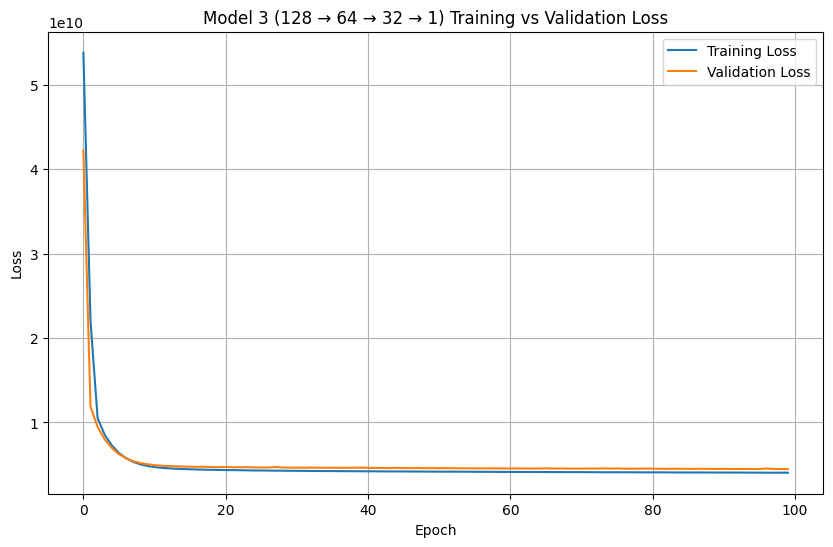

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 (128 → 64 → 32 → 1) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Model 4 (256 → 128 → 64 → 32 → 1) Loss Plot

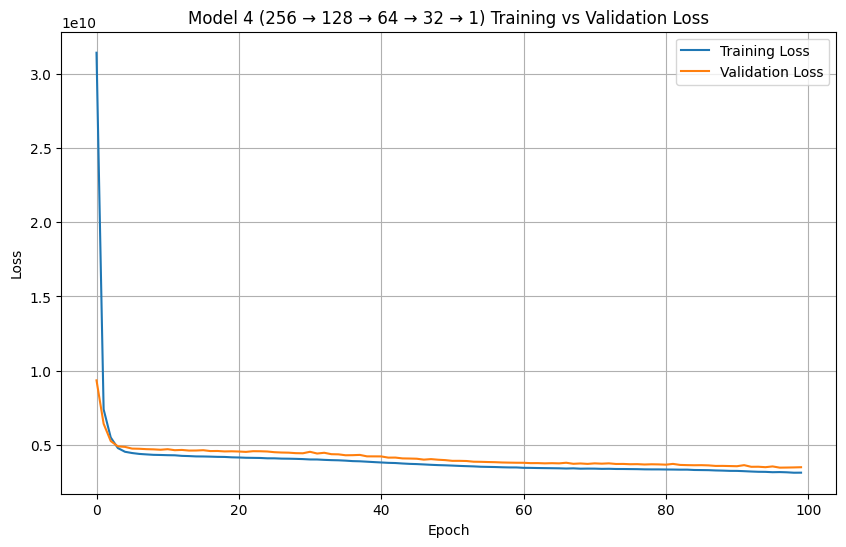

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history4.history['loss'], label='Training Loss')
plt.plot(history4.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 4 (256 → 128 → 64 → 32 → 1) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()